In [6]:
# =============================================================
# OMEGA — Ontario Multi-Objective Energy Grid Analyzer
#
# =============================================================

# ─────────────────────────────────────────────────────────────
# SECTION 0 — INSTALL & IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────
# Run this cell first — installs any missing packages
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "seaborn", "plotly", "matplotlib", "pandas",
                "numpy", "--quiet"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.rcParams.update({
    "figure.figsize":    (14, 5),
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         11,
})
COLORS = {
    "nuclear":  "#2196F3",
    "hydro":    "#00BCD4",
    "solar":    "#FFC107",
    "wind":     "#4CAF50",
    "biofuel":  "#8BC34A",
    "gas":      "#F44336",
    "demand":   "#9C27B0",
    "carbon":   "#FF5722",
    "cost":     "#3F51B5",
    "renewable":"#009688",
}
print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


In [9]:
# SECTION 1 — LOAD DATASET
# ─────────────────────────────────────────────────────────────
# Load from your processed data folder
df = pd.read_csv("merged_ontario_energy_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
 
print("=" * 55)
print("  OMEGA DATASET — BASIC OVERVIEW")
print("=" * 55)
print(f"  Total rows:      {len(df):,}")
print(f"  Total columns:   {df.shape[1]}")
print(f"  Date range:      {df['datetime'].min()} → {df['datetime'].max()}")
print(f"  Years covered:   {sorted(df['year'].unique())}")
print(f"  Missing values:  {df.isnull().sum().sum()}")
print(f"  Duplicate rows:  {df.duplicated().sum()}")
print("=" * 55)
 

  OMEGA DATASET — BASIC OVERVIEW
  Total rows:      96,264
  Total columns:   46
  Date range:      2015-01-08 00:00:00 → 2025-12-31 23:00:00
  Years covered:   [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Missing values:  0
  Duplicate rows:  0


In [10]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 — DATA QUALITY CHECK
# ─────────────────────────────────────────────────────────────
print("\n📋 SECTION 2 — Data Quality Check")
print("-" * 40)
 
# Check all key columns
key_cols = ["ontario_demand_mw", "nuclear_mw", "hydro_mw",
            "solar_mw", "wind_mw", "gas_mw", "biofuel_mw",
            "total_carbon_tonnes", "total_cost_cad",
            "temperature_c", "wind_speed_10m_ms",
            "solar_irradiance_kwh_m2", "renewable_share_pct",
            "grid_carbon_intensity"]
 
print("\n  Summary statistics for key variables:")
print(df[key_cols].describe().round(2).T[
    ["min", "mean", "50%", "max", "std"]
].to_string())
 
# Check for negative values (shouldn't exist in energy data)
print("\n  Negative value check:")
for col in ["ontario_demand_mw", "nuclear_mw", "hydro_mw",
            "solar_mw", "wind_mw", "gas_mw"]:
    neg = (df[col] < 0).sum()
    status = "✅" if neg == 0 else f"⚠️  {neg} negative values"
    print(f"    {col}: {status}")
 
# Distribution of seasons and years
print(f"\n  Records per year:")
print(df.groupby("year").size().to_string())
print(f"\n  Records per season:")
print(df.groupby("season").size().to_string())
 


📋 SECTION 2 — Data Quality Check
----------------------------------------

  Summary statistics for key variables:
                              min      mean       50%       max     std
ontario_demand_mw        12813.70  15770.11  15771.10  18736.90  919.96
nuclear_mw                7700.20   9500.10   9500.30  11182.50  399.77
hydro_mw                  1661.40   3800.05   3798.80   5895.60  533.11
solar_mw                     0.00    502.67    145.60   2297.70  622.53
wind_mw                      0.00   1206.00   1202.05   3647.50  581.09
gas_mw                       0.00    750.11    407.80   5188.60  874.87
biofuel_mw                 100.00    399.44    399.60    700.00   80.40
total_carbon_tonnes        242.30    698.50    526.92   2803.75  413.30
total_cost_cad             780.70   1073.15   1053.11   1653.61  129.43
temperature_c              -11.53     10.01     10.01     31.50    8.16
wind_speed_10m_ms            0.00      5.00      5.00     14.39    2.24
solar_irradiance_kwh


📊 SECTION 3 — Demand Analysis


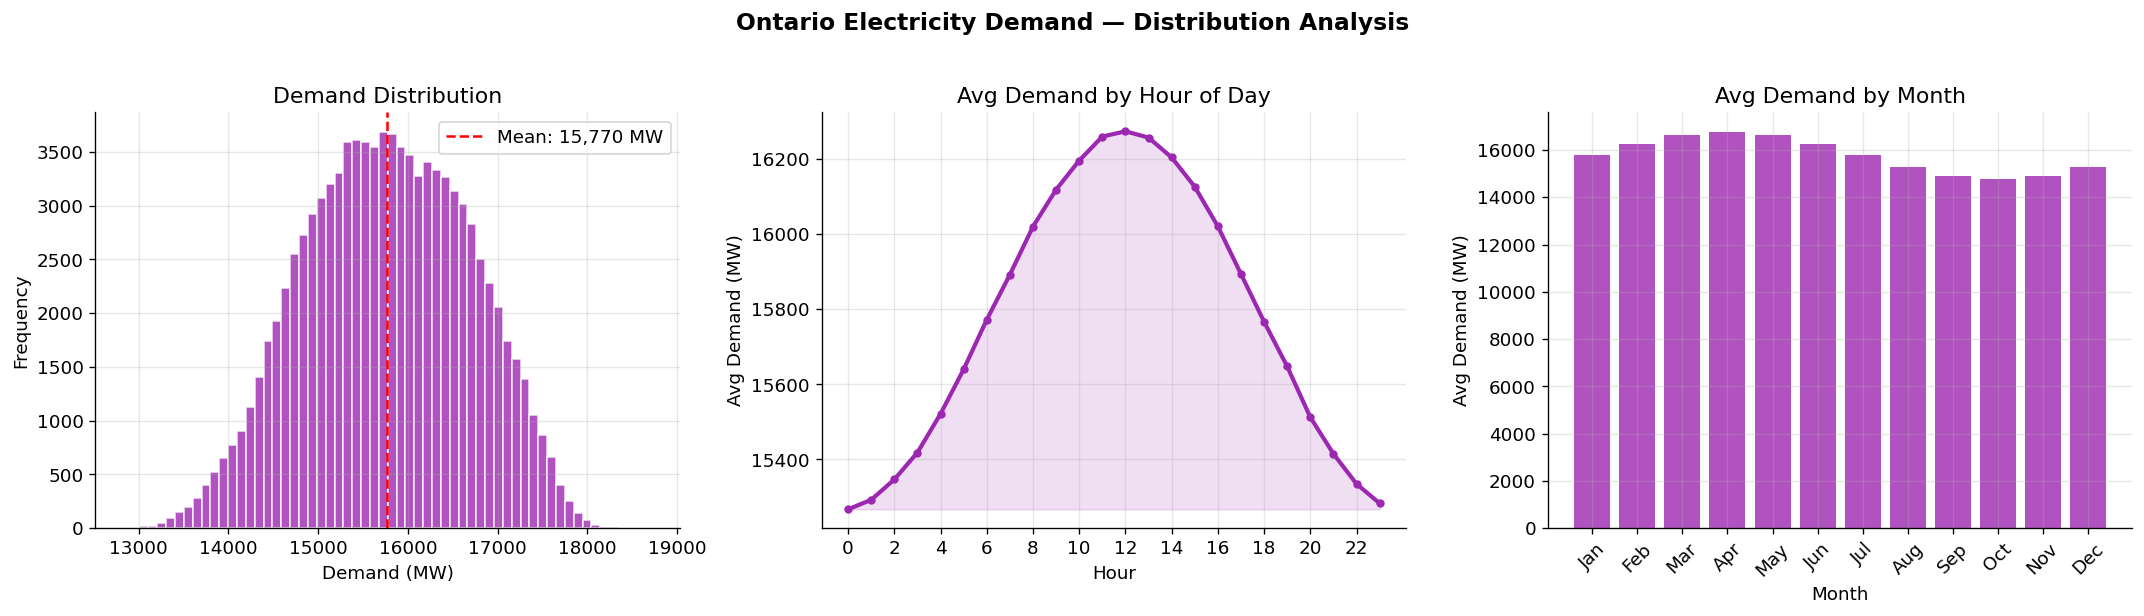

  ✅ Saved: 01_demand_distribution.png


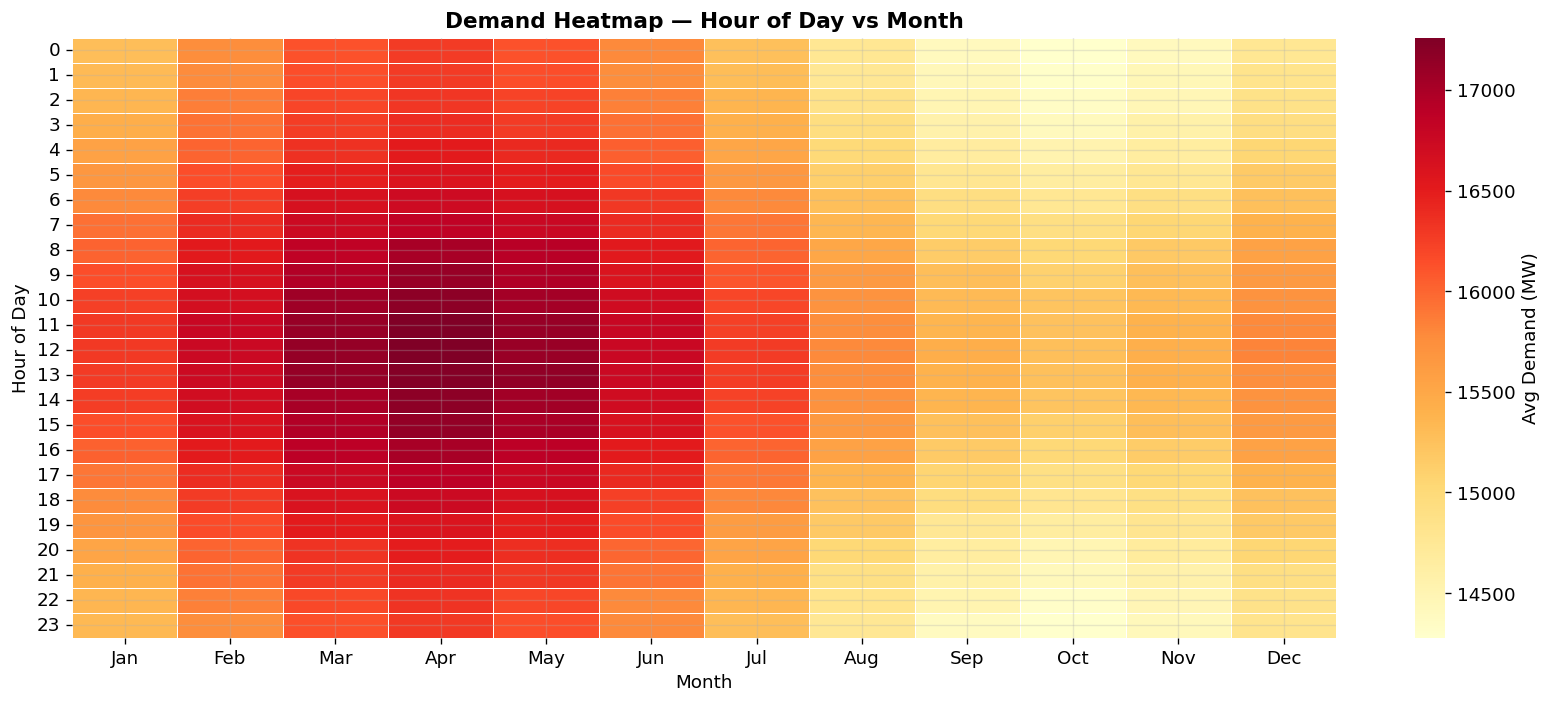

  ✅ Saved: 02_demand_heatmap.png


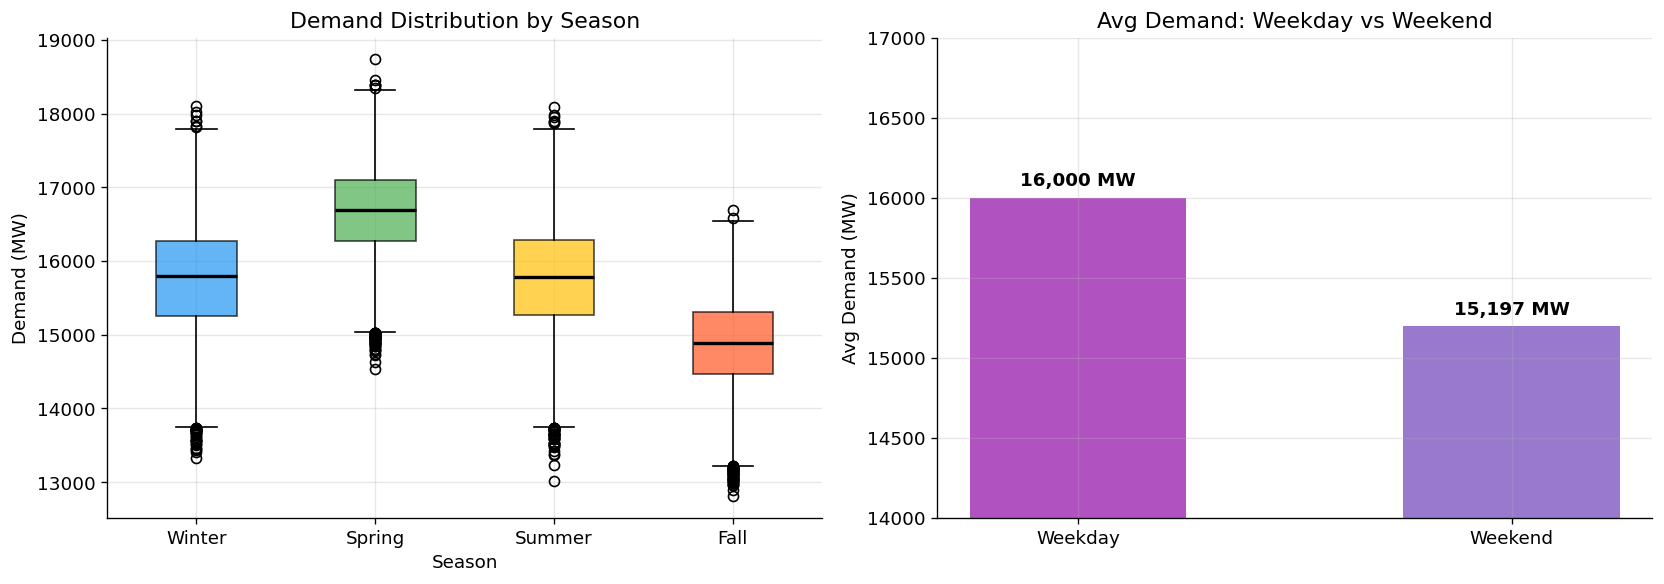

  ✅ Saved: 03_demand_season_weekend.png

  KEY DEMAND INSIGHTS:
  → Average demand:      15,770 MW
  → Peak demand:         18,737 MW
  → Minimum demand:      12,814 MW
  → Peak hour:           Hour 12
  → Peak month:          Apr
  → Weekday vs Weekend:  16,000 vs 15,197 MW


In [12]:
# SECTION 3 — DEMAND ANALYSIS
# ─────────────────────────────────────────────────────────────
print("\n📊 SECTION 3 — Demand Analysis")
 
# 3A — Overall demand distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Ontario Electricity Demand — Distribution Analysis",
             fontsize=14, fontweight="bold", y=1.02)
 
# Histogram
axes[0].hist(df["ontario_demand_mw"], bins=60,
             color=COLORS["demand"], alpha=0.8, edgecolor="white")
axes[0].axvline(df["ontario_demand_mw"].mean(), color="red",
                linestyle="--", label=f"Mean: {df['ontario_demand_mw'].mean():,.0f} MW")
axes[0].set_title("Demand Distribution")
axes[0].set_xlabel("Demand (MW)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
 
# By hour of day
hourly = df.groupby("hour")["ontario_demand_mw"].mean()
axes[1].plot(hourly.index, hourly.values, color=COLORS["demand"],
             linewidth=2.5, marker="o", markersize=4)
axes[1].fill_between(hourly.index, hourly.values,
                     hourly.min(), alpha=0.15, color=COLORS["demand"])
axes[1].set_title("Avg Demand by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Avg Demand (MW)")
axes[1].set_xticks(range(0, 24, 2))
 
# By month
monthly = df.groupby("month")["ontario_demand_mw"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[2].bar(range(1,13), monthly.values,
            color=COLORS["demand"], alpha=0.8)
axes[2].set_title("Avg Demand by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Avg Demand (MW)")
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(month_names, rotation=45)
plt.tight_layout()
plt.savefig("outputs/figures/01_demand_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 01_demand_distribution.png")
 
# 3B — Demand heatmap (hour vs month)
fig, ax = plt.subplots(figsize=(14, 6))
pivot = df.pivot_table(values="ontario_demand_mw",
                       index="hour", columns="month", aggfunc="mean")
pivot.columns = month_names
sns.heatmap(pivot, cmap="YlOrRd", annot=False,
            fmt=".0f", linewidths=0.3, ax=ax,
            cbar_kws={"label": "Avg Demand (MW)"})
ax.set_title("Demand Heatmap — Hour of Day vs Month",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.savefig("outputs/figures/02_demand_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 02_demand_heatmap.png")
 
# 3C — Demand by season and weekend vs weekday
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
season_order = ["Winter", "Spring", "Summer", "Fall"]
season_data  = [df[df["season"] == s]["ontario_demand_mw"]
                for s in season_order]
bp = axes[0].boxplot(season_data, labels=season_order,
                     patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
colors_season = ["#2196F3","#4CAF50","#FFC107","#FF5722"]
for patch, color in zip(bp["boxes"], colors_season):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("Demand Distribution by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Demand (MW)")
 
weekend_means = df.groupby("is_weekend")["ontario_demand_mw"].mean()
bars = axes[1].bar(["Weekday", "Weekend"], weekend_means.values,
                   color=[COLORS["demand"], "#7E57C2"],
                   alpha=0.8, width=0.5)
for bar, val in zip(bars, weekend_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 50, f"{val:,.0f} MW",
                 ha="center", va="bottom", fontweight="bold")
axes[1].set_title("Avg Demand: Weekday vs Weekend")
axes[1].set_ylabel("Avg Demand (MW)")
axes[1].set_ylim(14000, 17000)
plt.tight_layout()
plt.savefig("outputs/figures/03_demand_season_weekend.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 03_demand_season_weekend.png")
 
# Key demand insights
print(f"\n  KEY DEMAND INSIGHTS:")
print(f"  → Average demand:      {df['ontario_demand_mw'].mean():,.0f} MW")
print(f"  → Peak demand:         {df['ontario_demand_mw'].max():,.0f} MW")
print(f"  → Minimum demand:      {df['ontario_demand_mw'].min():,.0f} MW")
print(f"  → Peak hour:           Hour {df.groupby('hour')['ontario_demand_mw'].mean().idxmax()}")
print(f"  → Peak month:          {month_names[df.groupby('month')['ontario_demand_mw'].mean().idxmax()-1]}")
print(f"  → Weekday vs Weekend:  {weekend_means[0]:,.0f} vs {weekend_means[1]:,.0f} MW")
 


⚡ SECTION 4 — Energy Mix Analysis


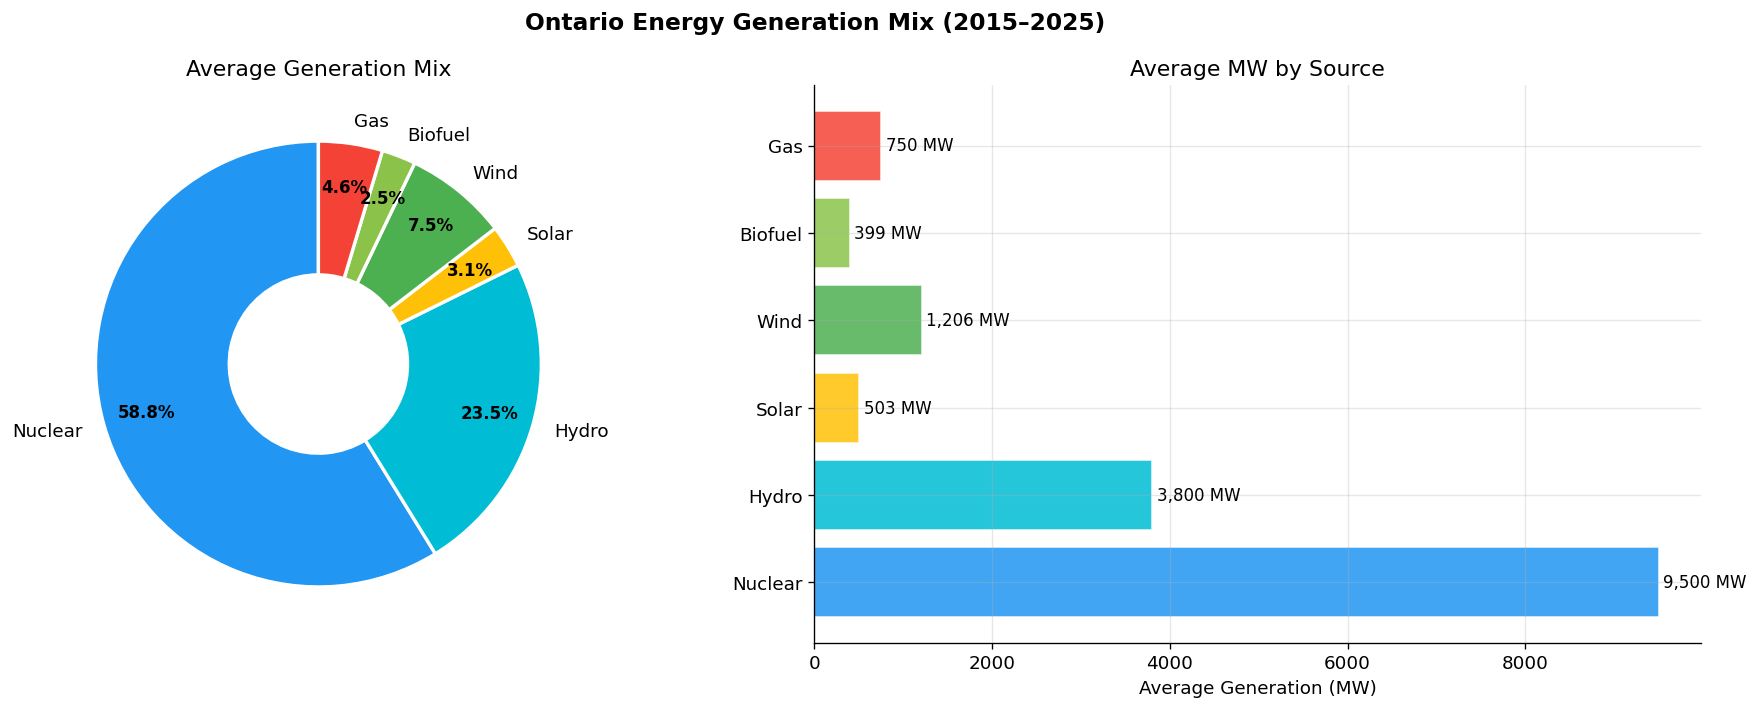

  ✅ Saved: 04_energy_mix.png


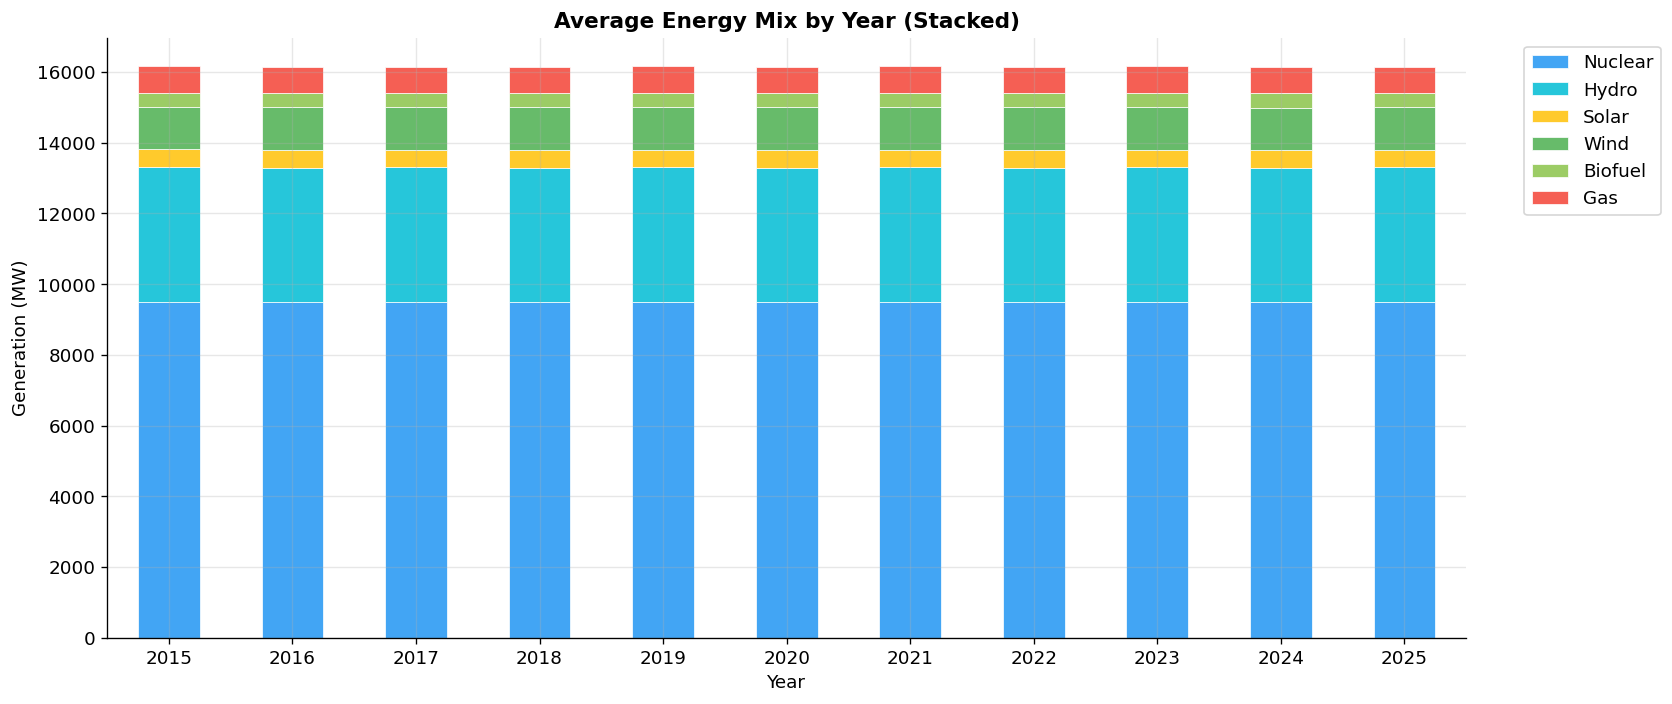

  ✅ Saved: 05_energy_mix_by_year.png


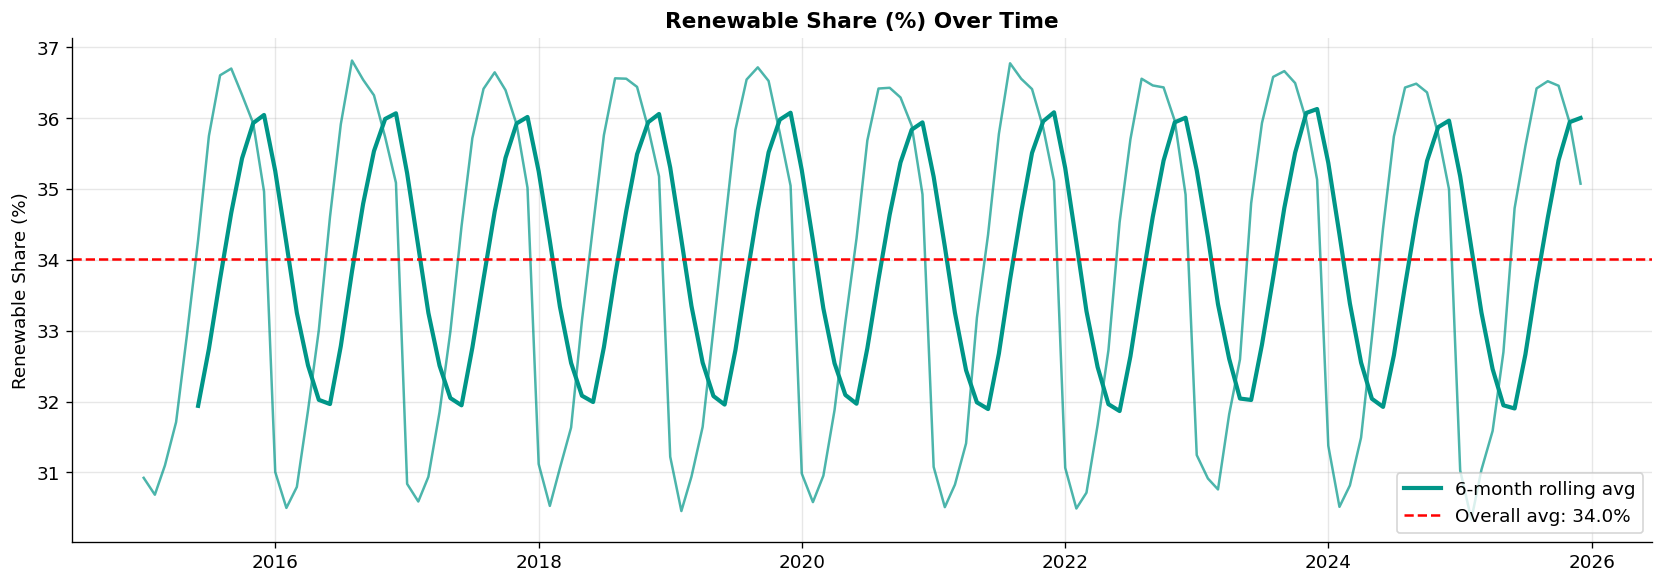

  ✅ Saved: 06_renewable_share_trend.png

  KEY ENERGY MIX INSIGHTS:
  → Nuclear   : 9,500 MW avg  (58.8%)
  → Hydro     : 3,800 MW avg  (23.5%)
  → Solar     : 503 MW avg  (3.1%)
  → Wind      : 1,206 MW avg  (7.5%)
  → Biofuel   : 399 MW avg  (2.5%)
  → Gas       : 750 MW avg  (4.6%)
  → Avg renewable share: 34.0%


In [13]:
# SECTION 4 — ENERGY MIX ANALYSIS
# ─────────────────────────────────────────────────────────────
print("\n⚡ SECTION 4 — Energy Mix Analysis")
 
fuel_cols = ["nuclear_mw","hydro_mw","solar_mw",
             "wind_mw","biofuel_mw","gas_mw"]
fuel_means = df[fuel_cols].mean()
fuel_labels = ["Nuclear","Hydro","Solar","Wind","Biofuel","Gas"]
fuel_colors = [COLORS[k.replace("_mw","")] for k in fuel_cols]
 
# 4A — Pie chart + bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ontario Energy Generation Mix (2015–2025)",
             fontsize=14, fontweight="bold")
 
wedges, texts, autotexts = axes[0].pie(
    fuel_means.values, labels=fuel_labels,
    colors=fuel_colors, autopct="%1.1f%%",
    startangle=90, pctdistance=0.8,
    wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2))
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")
axes[0].set_title("Average Generation Mix")
 
bars = axes[1].barh(fuel_labels, fuel_means.values,
                    color=fuel_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, fuel_means.values):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f"{val:,.0f} MW", va="center", fontsize=10)
axes[1].set_title("Average MW by Source")
axes[1].set_xlabel("Average Generation (MW)")
plt.tight_layout()
plt.savefig("outputs/figures/04_energy_mix.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 04_energy_mix.png")
 
# 4B — Generation mix by year (stacked bar)
fig, ax = plt.subplots(figsize=(14, 6))
yearly_mix = df.groupby("year")[fuel_cols].mean()
yearly_mix.columns = fuel_labels
yearly_mix.plot(kind="bar", stacked=True, ax=ax,
                color=fuel_colors, alpha=0.85,
                edgecolor="white", linewidth=0.5)
ax.set_title("Average Energy Mix by Year (Stacked)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Generation (MW)")
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
ax.set_xticklabels(yearly_mix.index, rotation=0)
plt.tight_layout()
plt.savefig("outputs/figures/05_energy_mix_by_year.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 05_energy_mix_by_year.png")
 
# 4C — Renewable share trend
fig, ax = plt.subplots(figsize=(14, 5))
monthly_renewable = df.groupby(["year","month"])["renewable_share_pct"].mean().reset_index()
monthly_renewable["date"] = pd.to_datetime(
    monthly_renewable[["year","month"]].assign(day=1))
ax.plot(monthly_renewable["date"],
        monthly_renewable["renewable_share_pct"],
        color=COLORS["renewable"], linewidth=1.5, alpha=0.7)
# Rolling average
ax.plot(monthly_renewable["date"],
        monthly_renewable["renewable_share_pct"].rolling(6).mean(),
        color=COLORS["renewable"], linewidth=2.5,
        label="6-month rolling avg")
ax.axhline(df["renewable_share_pct"].mean(), color="red",
           linestyle="--",
           label=f"Overall avg: {df['renewable_share_pct'].mean():.1f}%")
ax.set_title("Renewable Share (%) Over Time",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Renewable Share (%)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/06_renewable_share_trend.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 06_renewable_share_trend.png")
 
print(f"\n  KEY ENERGY MIX INSIGHTS:")
for label, col in zip(fuel_labels, fuel_cols):
    pct = fuel_means[col] / df["total_generation_mw"].mean() * 100
    print(f"  → {label:10s}: {fuel_means[col]:,.0f} MW avg  ({pct:.1f}%)")
print(f"  → Avg renewable share: {df['renewable_share_pct'].mean():.1f}%")
 


🔥 SECTION 5 — Gas Dispatch Analysis (Optimization Target)


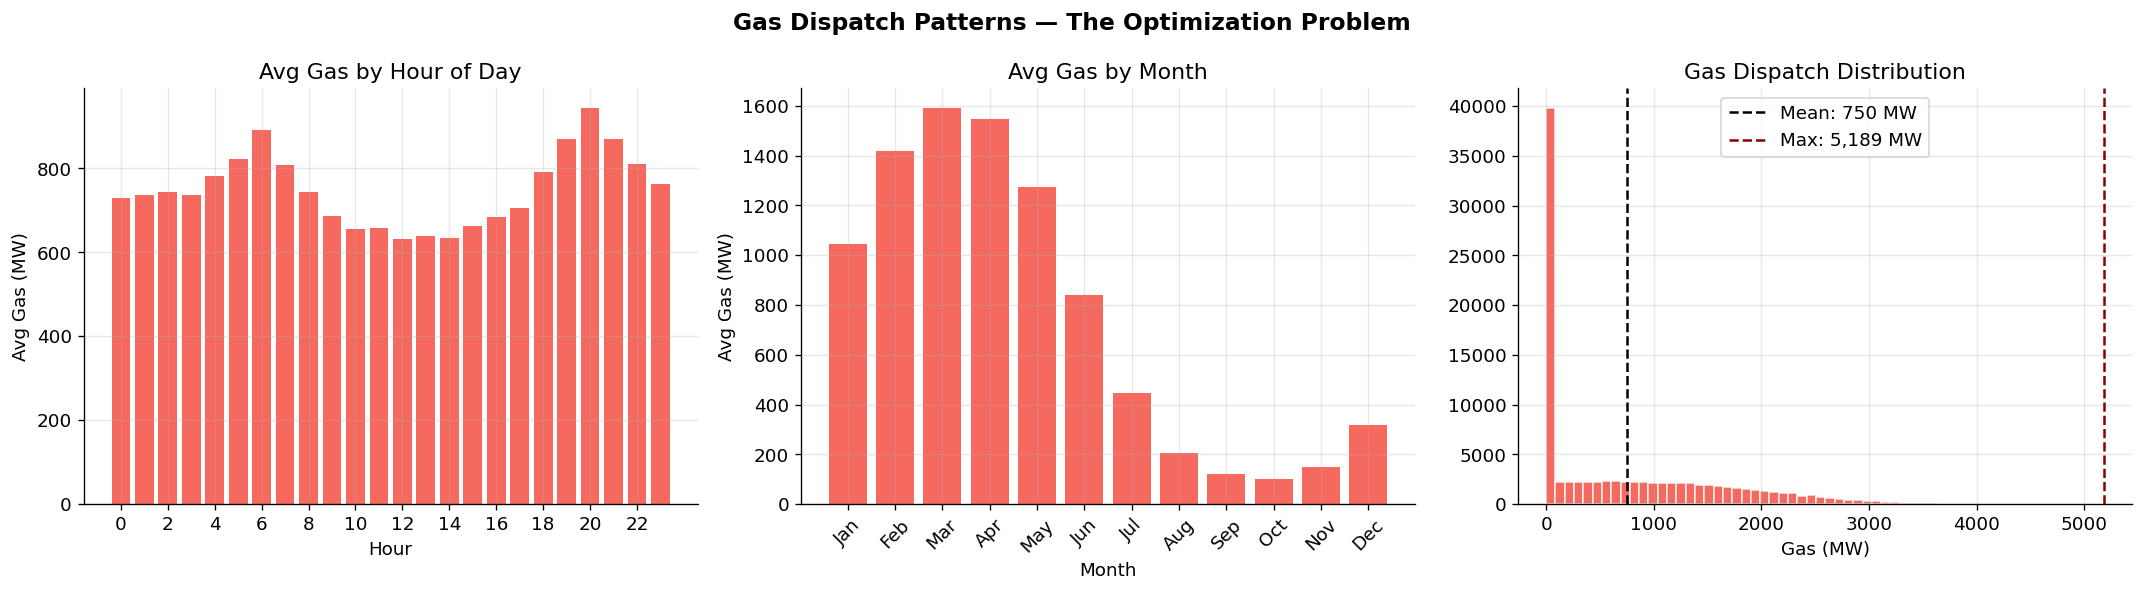

  ✅ Saved: 07_gas_dispatch_patterns.png


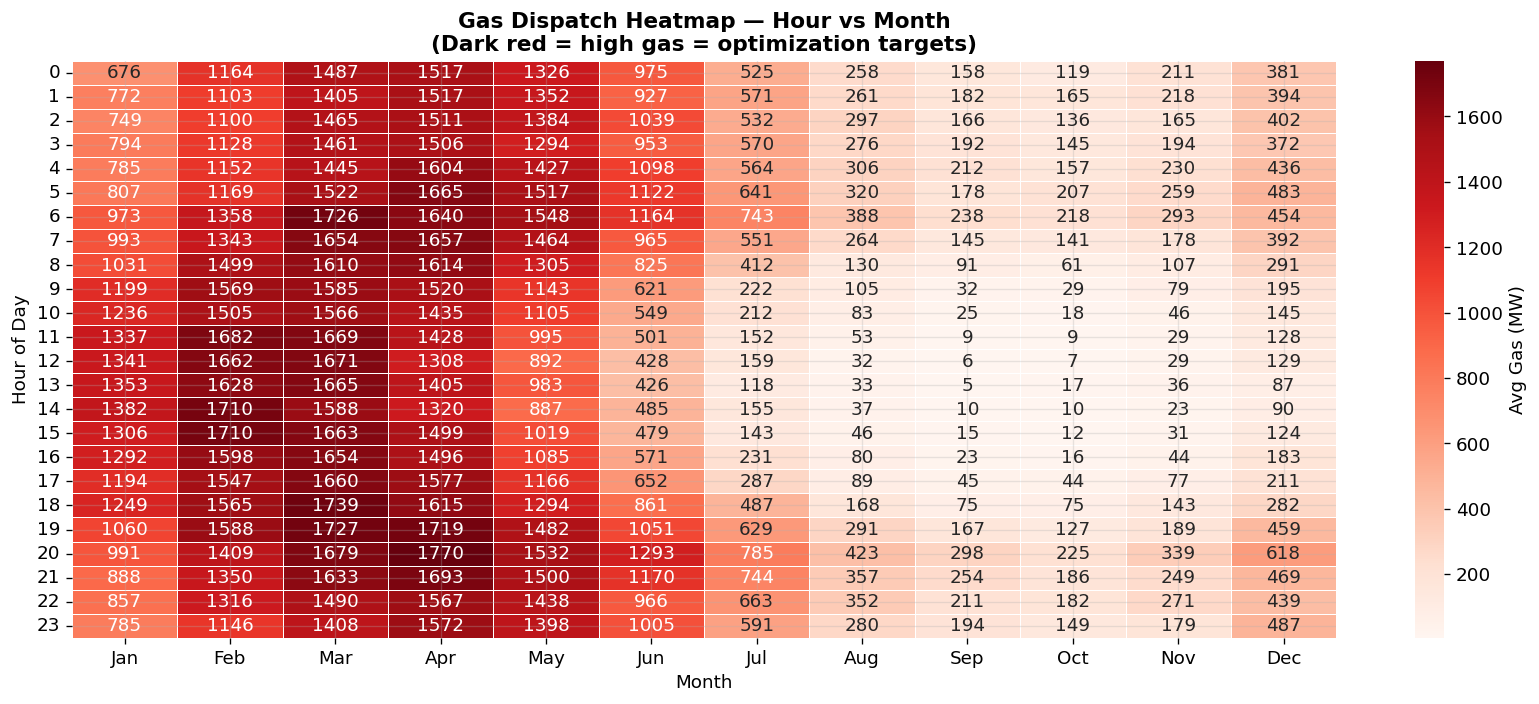

  ✅ Saved: 08_gas_heatmap.png


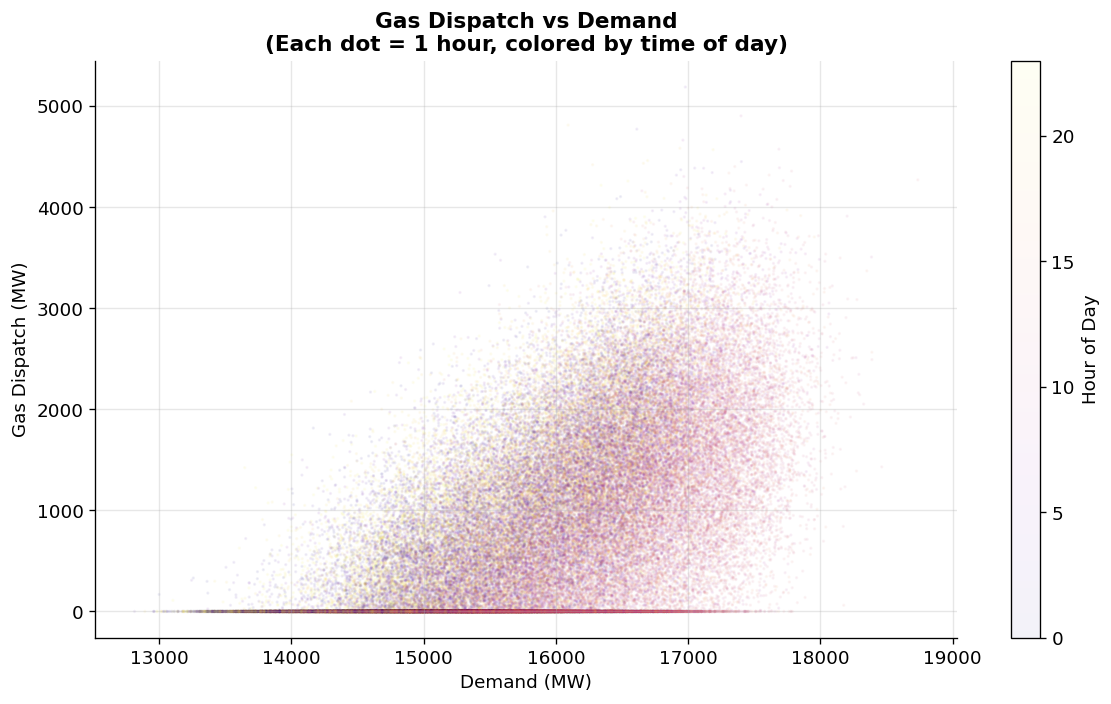

  ✅ Saved: 09_gas_vs_demand.png

  KEY GAS INSIGHTS (Optimization Targets):
  → Avg gas dispatch:    750 MW
  → Peak gas dispatch:   5,189 MW
  → High gas hours:      1,505 (1.6% of time)
  → High gas peak month: Mar
  → High gas peak hour:  Hour 20
  → These are the hours OMEGA will optimize!


In [14]:
# SECTION 5 — GAS DISPATCH ANALYSIS
# (This is the OPTIMIZATION target — why gas fires up)
# ─────────────────────────────────────────────────────────────
print("\n🔥 SECTION 5 — Gas Dispatch Analysis (Optimization Target)")
 
# 5A — Gas dispatch patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Gas Dispatch Patterns — The Optimization Problem",
             fontsize=14, fontweight="bold")
 
# Gas by hour
gas_hourly = df.groupby("hour")["gas_mw"].mean()
axes[0].bar(gas_hourly.index, gas_hourly.values,
            color=COLORS["gas"], alpha=0.8)
axes[0].set_title("Avg Gas by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg Gas (MW)")
axes[0].set_xticks(range(0, 24, 2))
 
# Gas by month
gas_monthly = df.groupby("month")["gas_mw"].mean()
axes[1].bar(range(1,13), gas_monthly.values,
            color=COLORS["gas"], alpha=0.8)
axes[1].set_title("Avg Gas by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Gas (MW)")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, rotation=45)
 
# Gas distribution
axes[2].hist(df["gas_mw"], bins=60,
             color=COLORS["gas"], alpha=0.8, edgecolor="white")
axes[2].axvline(df["gas_mw"].mean(), color="black",
                linestyle="--",
                label=f"Mean: {df['gas_mw'].mean():,.0f} MW")
axes[2].axvline(df["gas_mw"].max(), color="darkred",
                linestyle="--",
                label=f"Max: {df['gas_mw'].max():,.0f} MW")
axes[2].set_title("Gas Dispatch Distribution")
axes[2].set_xlabel("Gas (MW)")
axes[2].legend()
plt.tight_layout()
plt.savefig("outputs/figures/07_gas_dispatch_patterns.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 07_gas_dispatch_patterns.png")
 
# 5B — Gas heatmap (hour vs month)
fig, ax = plt.subplots(figsize=(14, 6))
gas_pivot = df.pivot_table(values="gas_mw",
                           index="hour",
                           columns="month",
                           aggfunc="mean")
gas_pivot.columns = month_names
sns.heatmap(gas_pivot, cmap="Reds", annot=True,
            fmt=".0f", linewidths=0.3, ax=ax,
            cbar_kws={"label": "Avg Gas (MW)"})
ax.set_title("Gas Dispatch Heatmap — Hour vs Month\n"
             "(Dark red = high gas = optimization targets)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.savefig("outputs/figures/08_gas_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 08_gas_heatmap.png")
 
# 5C — Gas vs demand scatter
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df["ontario_demand_mw"],
                     df["gas_mw"],
                     c=df["hour"], cmap="plasma",
                     alpha=0.05, s=1)
plt.colorbar(scatter, label="Hour of Day")
ax.set_title("Gas Dispatch vs Demand\n"
             "(Each dot = 1 hour, colored by time of day)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Demand (MW)")
ax.set_ylabel("Gas Dispatch (MW)")
plt.tight_layout()
plt.savefig("outputs/figures/09_gas_vs_demand.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 09_gas_vs_demand.png")
 
# High gas hours analysis
high_gas = df[df["high_gas_flag"] == 1]
print(f"\n  KEY GAS INSIGHTS (Optimization Targets):")
print(f"  → Avg gas dispatch:    {df['gas_mw'].mean():,.0f} MW")
print(f"  → Peak gas dispatch:   {df['gas_mw'].max():,.0f} MW")
print(f"  → High gas hours:      {len(high_gas):,} ({len(high_gas)/len(df)*100:.1f}% of time)")
print(f"  → High gas peak month: {month_names[gas_monthly.idxmax()-1]}")
print(f"  → High gas peak hour:  Hour {gas_hourly.idxmax()}")
print(f"  → These are the hours OMEGA will optimize!")
 


🌿 SECTION 6 — Carbon Emissions Analysis


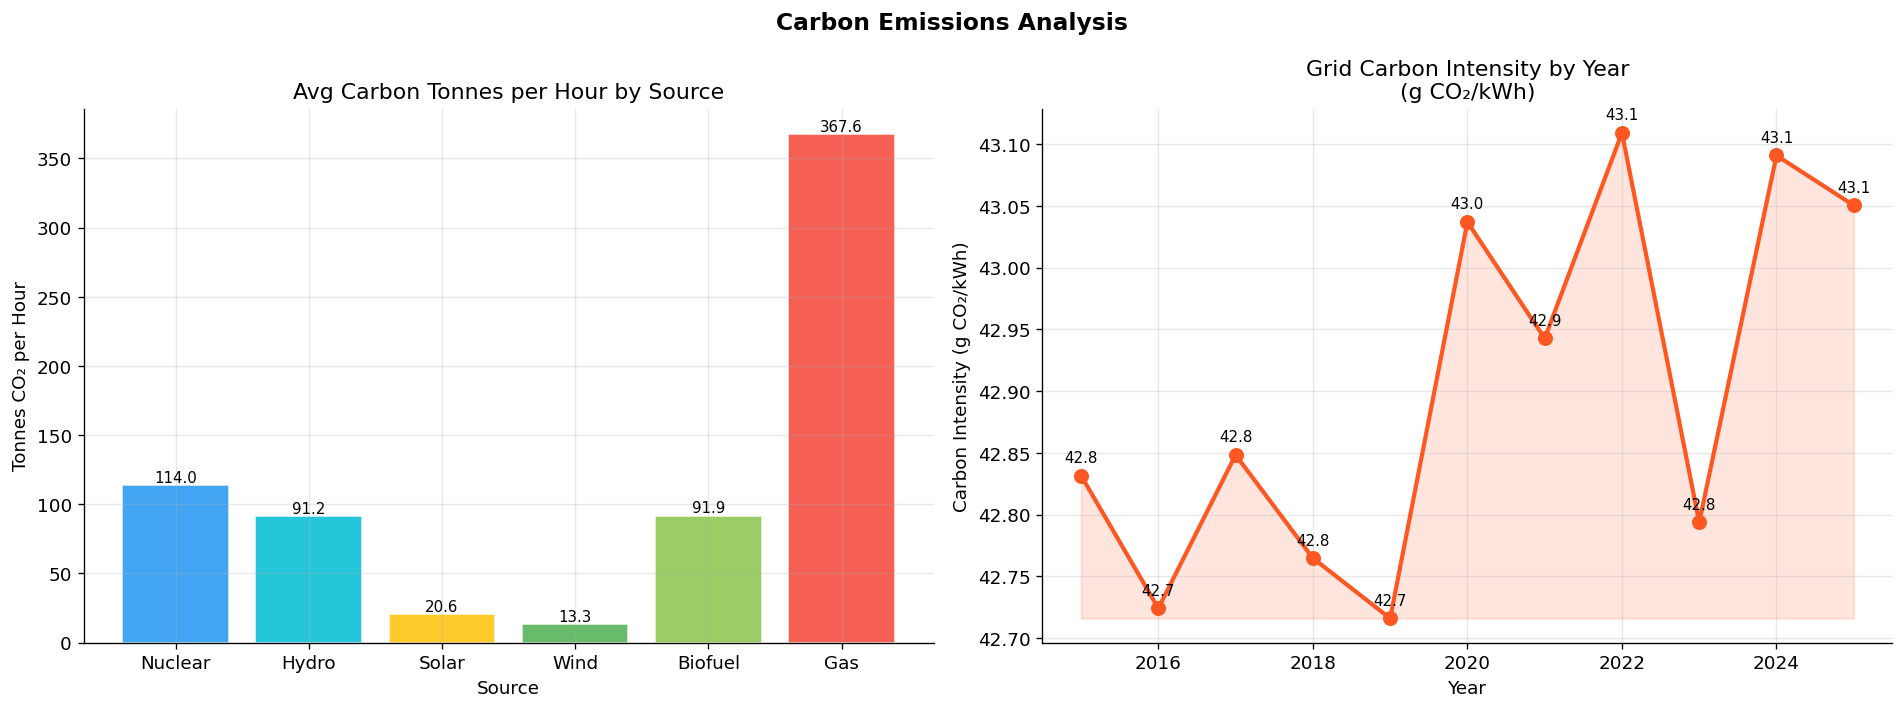

  ✅ Saved: 10_carbon_analysis.png


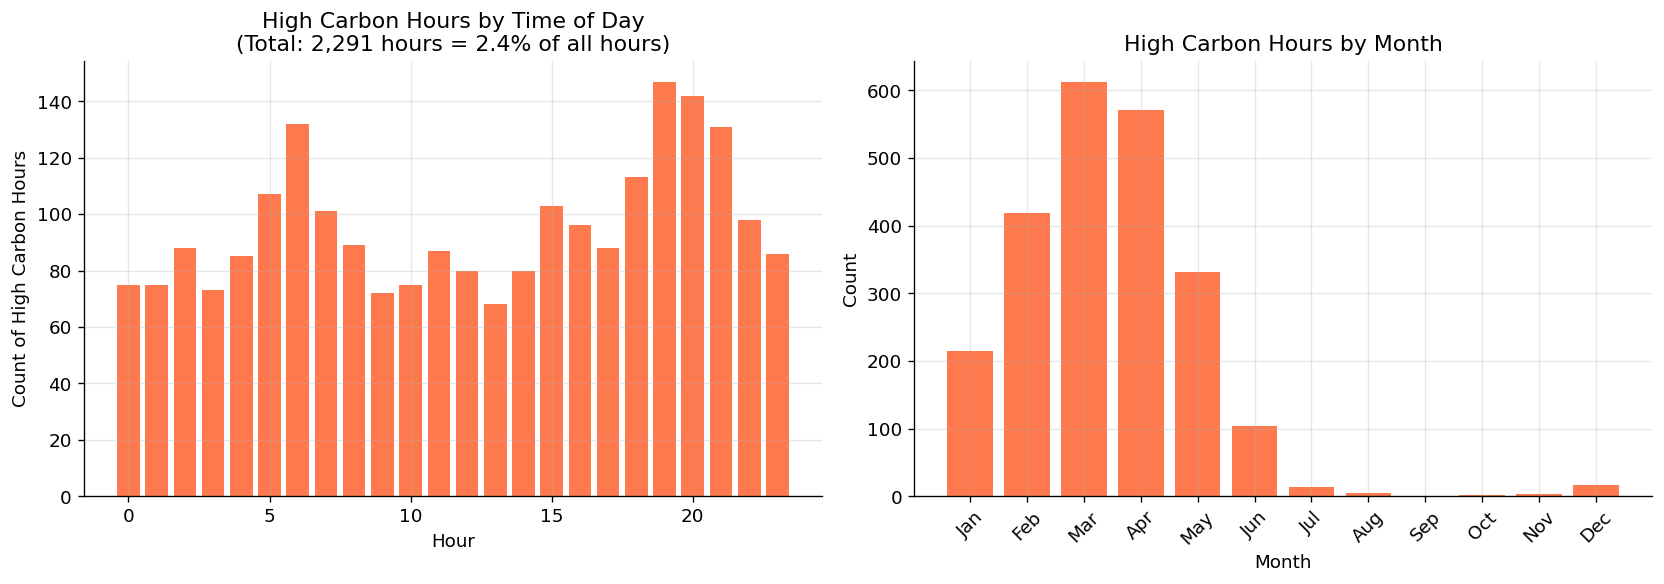

  ✅ Saved: 11_high_carbon_patterns.png

  KEY CARBON INSIGHTS:
  → Total CO₂ emitted (study period): 67.24 million tonnes
  → CO₂ from gas alone:               35.38 million tonnes
  → Gas % of total CO₂:               52.6%
  → Avg carbon intensity:             42.9 g CO₂/kWh
  → High carbon hours:                2,291
  → This is what OMEGA will REDUCE!


In [15]:
# SECTION 6 — CARBON ANALYSIS
# ─────────────────────────────────────────────────────────────
print("\n🌿 SECTION 6 — Carbon Emissions Analysis")
 
# 6A — Carbon breakdown by source
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Carbon Emissions Analysis",
             fontsize=14, fontweight="bold")
 
carbon_cols = ["carbon_tonnes_nuclear","carbon_tonnes_hydro",
               "carbon_tonnes_solar","carbon_tonnes_wind",
               "carbon_tonnes_biofuel","carbon_tonnes_gas"]
carbon_means = df[carbon_cols].mean()
carbon_labels = ["Nuclear","Hydro","Solar","Wind","Biofuel","Gas"]
 
bars = axes[0].bar(carbon_labels, carbon_means.values,
                   color=fuel_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, carbon_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.1, f"{val:.1f}",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("Avg Carbon Tonnes per Hour by Source")
axes[0].set_ylabel("Tonnes CO₂ per Hour")
axes[0].set_xlabel("Source")
 
# Carbon intensity over years
yearly_carbon = df.groupby("year")["grid_carbon_intensity"].mean()
axes[1].plot(yearly_carbon.index, yearly_carbon.values,
             color=COLORS["carbon"], linewidth=2.5,
             marker="o", markersize=8)
axes[1].fill_between(yearly_carbon.index, yearly_carbon.values,
                     yearly_carbon.min(), alpha=0.15,
                     color=COLORS["carbon"])
for x, y in zip(yearly_carbon.index, yearly_carbon.values):
    axes[1].annotate(f"{y:.1f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)
axes[1].set_title("Grid Carbon Intensity by Year\n(g CO₂/kWh)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Carbon Intensity (g CO₂/kWh)")
plt.tight_layout()
plt.savefig("outputs/figures/10_carbon_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 10_carbon_analysis.png")
 
# 6B — High carbon hour patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
high_carbon = df[df["high_carbon_flag"] == 1]
 
high_carbon_by_hour = high_carbon.groupby("hour").size()
axes[0].bar(high_carbon_by_hour.index,
            high_carbon_by_hour.values,
            color=COLORS["carbon"], alpha=0.8)
axes[0].set_title(f"High Carbon Hours by Time of Day\n"
                  f"(Total: {len(high_carbon):,} hours = "
                  f"{len(high_carbon)/len(df)*100:.1f}% of all hours)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count of High Carbon Hours")
 
high_carbon_by_month = high_carbon.groupby("month").size()
axes[1].bar(range(1,13), high_carbon_by_month.reindex(
    range(1,13), fill_value=0).values,
    color=COLORS["carbon"], alpha=0.8)
axes[1].set_title("High Carbon Hours by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, rotation=45)
plt.tight_layout()
plt.savefig("outputs/figures/11_high_carbon_patterns.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 11_high_carbon_patterns.png")
 
total_co2 = df["total_carbon_tonnes"].sum()
gas_co2   = df["carbon_tonnes_gas"].sum()
print(f"\n  KEY CARBON INSIGHTS:")
print(f"  → Total CO₂ emitted (study period): {total_co2/1e6:.2f} million tonnes")
print(f"  → CO₂ from gas alone:               {gas_co2/1e6:.2f} million tonnes")
print(f"  → Gas % of total CO₂:               {gas_co2/total_co2*100:.1f}%")
print(f"  → Avg carbon intensity:             {df['grid_carbon_intensity'].mean():.1f} g CO₂/kWh")
print(f"  → High carbon hours:                {len(high_carbon):,}")
print(f"  → This is what OMEGA will REDUCE!")
 

In [16]:
# SECTION 7 — COST ANALYSIS
# ─────────────────────────────────────────────────────────────
print("\n💰 SECTION 7 — Cost Analysis")
 
# 7A — Cost breakdown by source
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Generation Cost Analysis",
             fontsize=14, fontweight="bold")
 
cost_cols = ["cost_cad_nuclear","cost_cad_hydro","cost_cad_solar",
             "cost_cad_wind","cost_cad_biofuel","cost_cad_gas"]
cost_means = df[cost_cols].mean()
cost_labels = ["Nuclear","Hydro","Solar","Wind","Biofuel","Gas"]
 
bars = axes[0].bar(cost_labels, cost_means.values,
                   color=fuel_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, cost_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 10, f"${val:,.0f}",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("Avg Hourly Cost by Source (CAD)")
axes[0].set_ylabel("CAD per Hour")
 
# Cost vs carbon scatter — THE KEY CHART
sc = axes[1].scatter(df["total_cost_cad"],
                     df["total_carbon_tonnes"],
                     c=df["gas_mw"], cmap="Reds",
                     alpha=0.05, s=1)
plt.colorbar(sc, ax=axes[1], label="Gas MW")
axes[1].set_title("Cost vs Carbon — The Optimization Tradeoff\n"
                  "(Red = high gas — OMEGA targets these hours)",
                  fontsize=11)
axes[1].set_xlabel("Total Cost (CAD/hr)")
axes[1].set_ylabel("Total Carbon (tonnes/hr)")
plt.tight_layout()
plt.savefig("outputs/figures/12_cost_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 12_cost_analysis.png")
 
annual_cost = df["total_cost_cad"].sum()
gas_cost    = df["cost_cad_gas"].sum()
print(f"\n  RAW COST CHECK:")
print(f"  → total_cost_cad mean:  {df['total_cost_cad'].mean():,.2f}")
print(f"  → cost_cad_gas mean:    {df['cost_cad_gas'].mean():,.2f}")
annual_cost_m = df["total_cost_cad"].sum() / 1e6
gas_cost_m    = df["cost_cad_gas"].sum() / 1e6
print(f"\n  KEY COST INSIGHTS:")
print(f"  → Total cost (study period): ${annual_cost_m:,.1f} million CAD")
print(f"  → Gas cost alone:            ${gas_cost_m:,.1f} million CAD")
print(f"  → Gas % of total cost:       {gas_cost/annual_cost*100:.1f}%")
print(f"  → Avg hourly total cost:     ${df['total_cost_cad'].mean():,.2f} CAD")
 

In [17]:
# SECTION 8 — WEATHER & RENEWABLE CORRELATION
# ─────────────────────────────────────────────────────────────
print("\n🌤️ SECTION 8 — Weather vs Renewable Correlation")
 
# 8A — Solar irradiance vs solar generation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Weather Variables vs Renewable Generation",
             fontsize=14, fontweight="bold")
 
# Daytime only for solar
daytime = df[df["hour"].between(6, 20)]
axes[0].scatter(daytime["solar_irradiance_kwh_m2"],
                daytime["solar_mw"],
                c=daytime["month"], cmap="YlOrRd",
                alpha=0.1, s=2)
axes[0].set_title("Solar Irradiance vs Solar Generation\n"
                  "(Daytime hours only, colored by month)")
axes[0].set_xlabel("Solar Irradiance (kWh/m²)")
axes[0].set_ylabel("Solar Generation (MW)")
 
# Wind speed vs wind generation
axes[1].scatter(df["wind_speed_50m_ms"],
                df["wind_mw"],
                c=df["season"].map(
                    {"Winter":0,"Spring":1,"Summer":2,"Fall":3}),
                cmap="RdYlGn", alpha=0.05, s=1)
axes[1].set_title("Wind Speed vs Wind Generation\n"
                  "(Colored by season)")
axes[1].set_xlabel("Wind Speed at 50m (m/s)")
axes[1].set_ylabel("Wind Generation (MW)")
plt.tight_layout()
plt.savefig("outputs/figures/13_weather_renewable_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 13_weather_renewable_scatter.png")
 
# 8B — Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))
corr_cols = ["ontario_demand_mw","solar_mw","wind_mw",
             "gas_mw","temperature_c","wind_speed_50m_ms",
             "solar_irradiance_kwh_m2","relative_humidity_pct",
             "grid_carbon_intensity","total_cost_cad",
             "renewable_share_pct"]
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True,
            fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Correlation"},
            annot_kws={"size": 9})
ax.set_title("Correlation Matrix — Key Variables\n"
             "(Green = positive, Red = negative)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/14_correlation_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 14_correlation_matrix.png")
 
# Print key correlations
print(f"\n  KEY WEATHER CORRELATIONS:")
print(f"  → Solar irradiance → Solar gen:   "
      f"{df['solar_irradiance_kwh_m2'].corr(df['solar_mw']):.3f}")
print(f"  → Wind 10m → Wind gen:  {df['wind_speed_10m_ms'].corr(df['wind_mw']):.3f}  (weaker — surface level)")
print(f"  → Wind 50m → Wind gen:  {df['wind_speed_50m_ms'].corr(df['wind_mw']):.3f}  ← using this in ensemble ✅")
print(f"  → Temperature → Demand:           "
      f"{df['temperature_c'].corr(df['ontario_demand_mw']):.3f}")
print(f"  → Temperature → Gas:              "
      f"{df['temperature_c'].corr(df['gas_mw']):.3f}")
print(f"  → Renewable share → Carbon:       "
      f"{df['renewable_share_pct'].corr(df['grid_carbon_intensity']):.3f}")
print(f"  → All correlations validate H3!")
 


🕐 SECTION 9 — Lag Feature Validation


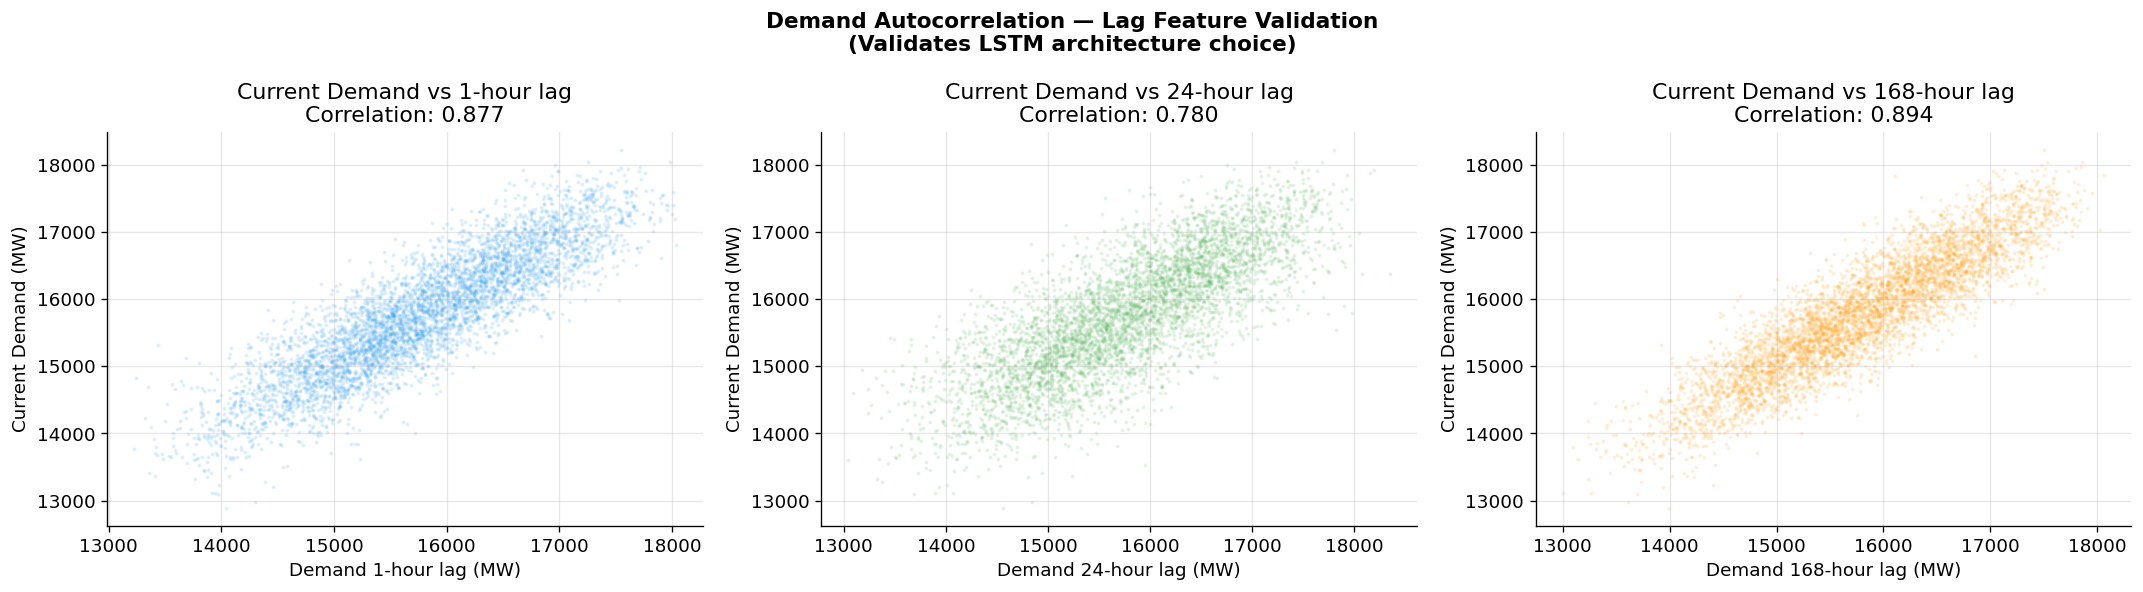

  ✅ Saved: 15_lag_validation.png


In [18]:
# SECTION 9 — LAG FEATURE VALIDATION
# (Important for LSTM model design)
# ─────────────────────────────────────────────────────────────
print("\n🕐 SECTION 9 — Lag Feature Validation")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Demand Autocorrelation — Lag Feature Validation\n"
             "(Validates LSTM architecture choice)",
             fontsize=13, fontweight="bold")
 
lag_cols = {
    "1-hour lag":   "demand_lag1h",
    "24-hour lag":  "demand_lag24h",
    "168-hour lag": "demand_lag168h"
}
lag_colors = ["#2196F3","#4CAF50","#FF9800"]
 
for ax, (label, col), color in zip(axes, lag_cols.items(), lag_colors):
    sample = df.dropna(subset=[col]).sample(5000, random_state=42)
    corr   = sample["ontario_demand_mw"].corr(sample[col])
    ax.scatter(sample[col], sample["ontario_demand_mw"],
               alpha=0.1, s=2, color=color)
    ax.set_title(f"Current Demand vs {label}\n"
                 f"Correlation: {corr:.3f}")
    ax.set_xlabel(f"Demand {label} (MW)")
    ax.set_ylabel("Current Demand (MW)")
 
plt.tight_layout()
plt.savefig("outputs/figures/15_lag_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved: 15_lag_validation.png")
 
# ─────────────────────────────────────────────────────────────

In [20]:
# SECTION 10 — EDA SUMMARY & KEY FINDINGS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  OMEGA EDA — KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"""
  DATASET:
  → 96,264 hourly records (2015–2025), 46 features, zero nulls
  → Covers all seasons, years, fuel types, weather variables
 
  DEMAND:
  → Avg demand: {df['ontario_demand_mw'].mean():,.0f} MW
  → Peak: {df['ontario_demand_mw'].max():,.0f} MW (winter mornings)
  → Weekday avg: {df[df["is_weekend"]==0]["ontario_demand_mw"].mean():,.0f} MW  |  Weekend avg: {df[df["is_weekend"]==1]["ontario_demand_mw"].mean():,.0f} MW
  → Weekday is {df[df["is_weekend"]==0]["ontario_demand_mw"].mean() - df[df["is_weekend"]==1]["ontario_demand_mw"].mean():,.0f} MW HIGHER than weekend ✅
  → Strong hourly and seasonal patterns → validates LSTM choice
 
  ENERGY MIX:
  → Nuclear dominates (~60%), hydro (~24%)
  → Gas averages {df['gas_mw'].mean():,.0f} MW but peaks at {df['gas_mw'].max():,.0f} MW
  → Renewable share averages {df['renewable_share_pct'].mean():.1f}% — room to improve
 
  CARBON:
  → Total CO₂: {df['total_carbon_tonnes'].sum()/1e6:.2f} million tonnes over study period
  → Gas contributes {df['carbon_tonnes_gas'].sum()/df['total_carbon_tonnes'].sum()*100:.1f}% of all CO₂
  → {len(high_carbon):,} high-carbon hours identified as optimization targets
 
  COST:
  → Gas contributes {df['cost_cad_gas'].sum()/df['total_cost_cad'].sum()*100:.1f}% of total cost
  → Reducing gas dispatch is both cheapest AND cleanest solution
 
  WEATHER:
  → Solar irradiance → solar gen: r = {df['solar_irradiance_kwh_m2'].corr(df['solar_mw']):.3f} ✅
  → Wind 50m → wind gen:   r = {df["wind_speed_50m_ms"].corr(df["wind_mw"]):.3f} ✅  (50m height used for ensemble)
  → Validates NASA POWER weather data as strong model input
 
  LAG FEATURES:
  → 1h lag corr: {df['demand_lag1h'].corr(df['ontario_demand_mw']):.3f}
  → 24h lag corr: {df['demand_lag24h'].corr(df['ontario_demand_mw']):.3f}
  → 168h lag corr: {df['demand_lag168h'].corr(df['ontario_demand_mw']):.3f}
  → All strong → validates stacking ensemble with LSTM + ARIMA
 
  OPTIMIZATION TARGETS IDENTIFIED:
  → Winter mornings (6–9am): highest gas dispatch
  → Summer afternoons (2–6pm): solar + wind can replace gas
  → {len(high_carbon):,} high-carbon hours are primary optimization targets
  → Reducing gas from {df['gas_mw'].mean():,.0f} MW avg is the OMEGA mission
""")






























